<a href="https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acoustic analysis of Chuvash vowels

1. Obtain acoustic data

Chuvash-Voice

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio

chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

KeyboardInterrupt: 

Common-Voice

Usage Instructions:
1. Replace YOUR_API_KEY with your actual API key in both commands
1.   Run the create download session command to get a download token
2. Replace DOWNLOAD_TOKEN with the token from step 1
3. Run the download command to get the dataset file

In [ ]:
curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

In [ ]:
curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

Common Voice Chuvash textgrids from Vox Communis

Phonology class

2. Pre-process for Montreal Forced Aligner (MFA)

3. Run MFA

4. Pre-process for FAVE vowel extraction

chuvash-manual-recode.py

5. Run new-FAVE

In [ ]:
!pip install new-fave

In [ ]:
chuvash-fave.py

6. Combine extracted vowel data

chuvash-combine.py

7. Visualize results

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Define Path to the COMBINED CSV ---
base_corpus_path = "/content"
combined_csv_path = os.path.join(base_corpus_path, "all_chuvash_vowel_points.csv")

# --- Load the combined data ONCE ---
try:
    combined_df = pd.read_csv(combined_csv_path, encoding='utf-8')
    print(f"Successfully loaded combined data with {len(combined_df)} entries.")
    print("Columns available:", combined_df.columns.tolist())

    # Filter for only vowel labels (exclude SIL and any non-vowel markers)
    # Adjust this list if you have other non-vowel labels you want to exclude
    vowels_df = combined_df[~combined_df['label'].isin(['SIL', '<eps>', '#'])].copy()
    print(f"Filtered for vowels: {len(vowels_df)} entries remaining.")

except FileNotFoundError:
    print(f"Error: Combined CSV file not found at '{combined_csv_path}'. Please run 'combine_fave_points_data.py' first.")
    # Exit or handle the error appropriately if running as a script
    # For a notebook, you might just display an error and let the user fix it.
except Exception as e:
    print(f"An error occurred while loading or preparing data: {e}")
    # Handle error
    vowels_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors if loading fails

Successfully loaded combined data with 4006 entries.
Columns available: ['F1', 'F2', 'F3', 'B1', 'B2', 'B3', 'max_formant', 'smooth_error', 'time', 'rel_time', 'prop_time', 'id', 'label', 'file_name', 'group', 'speaker_num', 'point_heuristic', 'f0', 'intensity', 'optimized', 'word', 'stress', 'dur', 'pre_word', 'fol_word', 'pre_seg', 'fol_seg', 'abs_pre_seg', 'abs_fol_seg', 'context']
Filtered for vowels: 3508 entries remaining.


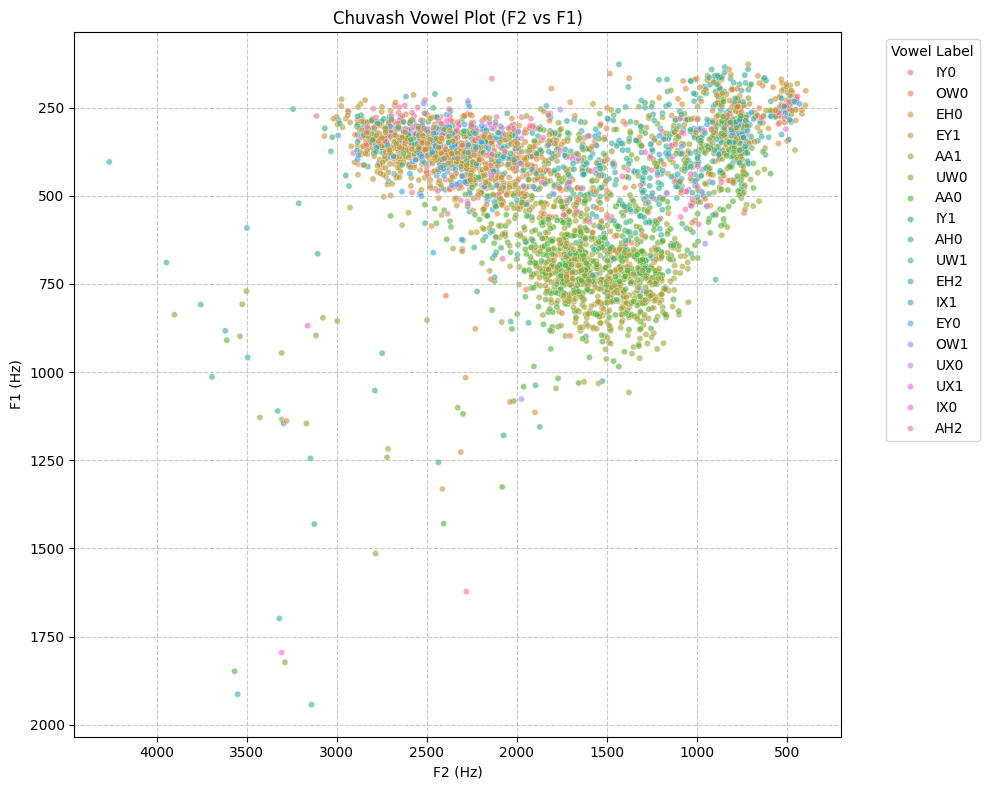

In [ ]:
# Cell 1: Basic Vowel Plot (F2 vs F1)
if not vowels_df.empty:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=vowels_df, x='F2', y='F1', hue='label', alpha=0.6, s=20)
    plt.gca().invert_xaxis() # Invert F2 axis as is common in phonetics
    plt.gca().invert_yaxis() # Invert F1 axis as is common in phonetics
    plt.title('Chuvash Vowel Plot (F2 vs F1)')
    plt.xlabel('F2 (Hz)')
    plt.ylabel('F1 (Hz)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Vowel Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1/F2 plot.")

/tmp/ipython-input-1446105758.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=vowels_df, x='label', y='F1', inner='quartile', palette='viridis')


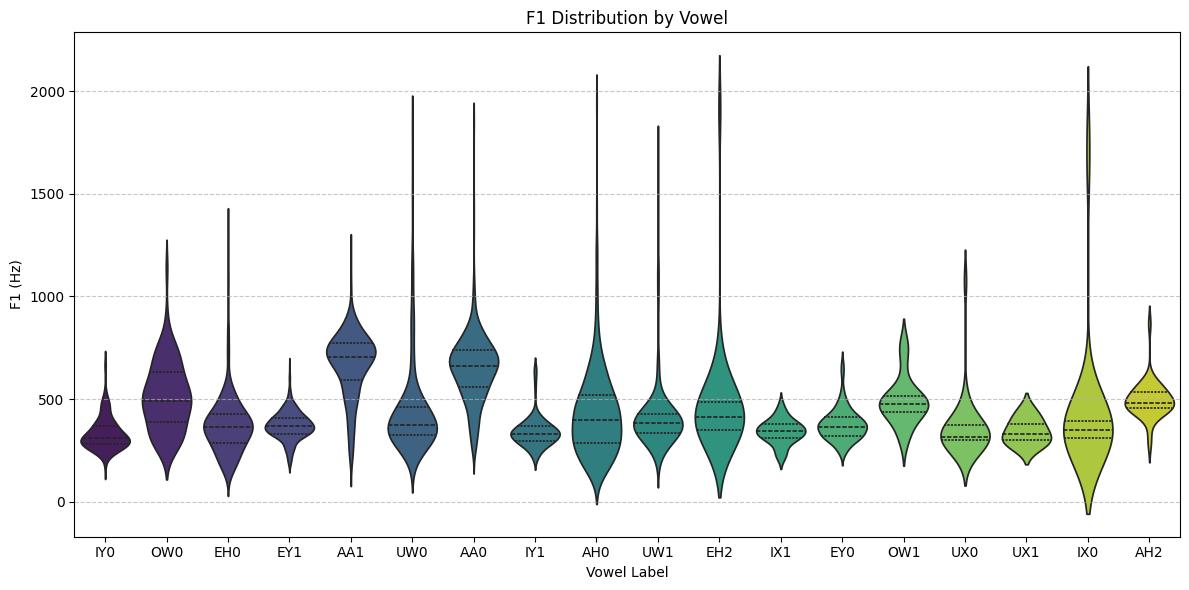

In [ ]:
# Cell 2: F1 Distribution by Vowel
if not vowels_df.empty:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=vowels_df, x='label', y='F1', inner='quartile', palette='viridis')
    plt.title('F1 Distribution by Vowel')
    plt.xlabel('Vowel Label')
    plt.ylabel('F1 (Hz)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1 distribution plot.")

/tmp/ipython-input-3514153574.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vowels_df, x='label', y='dur', palette='plasma')


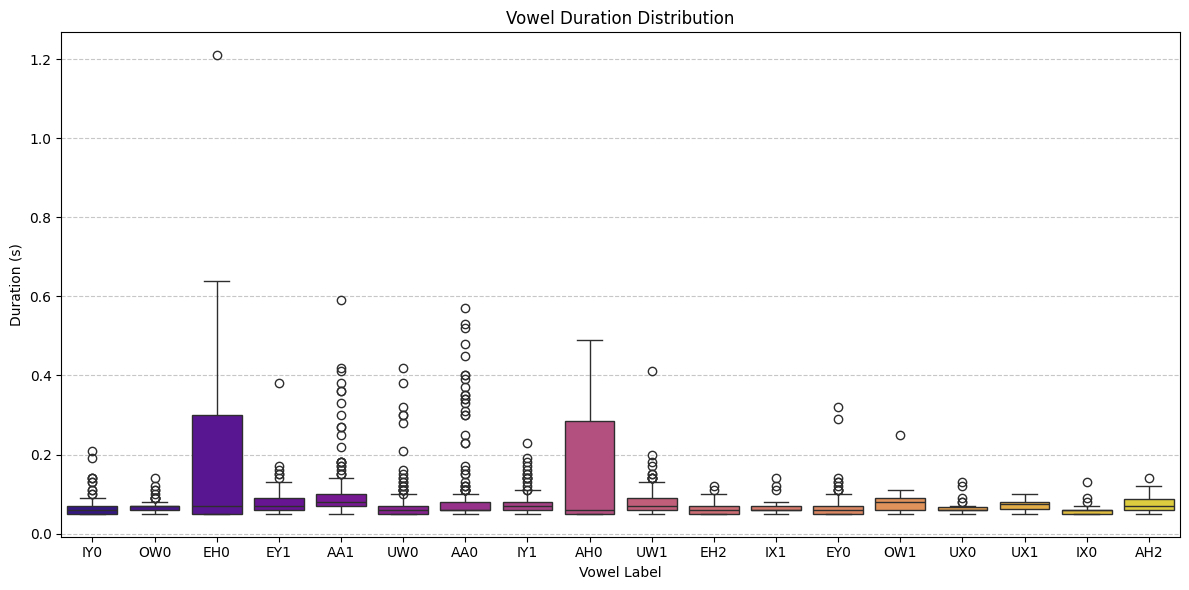

In [ ]:
# Cell 3: Duration Distribution by Vowel
if not vowels_df.empty:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=vowels_df, x='label', y='dur', palette='plasma')
    plt.title('Vowel Duration Distribution')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-1242498643.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 35.05, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1   0.0149    0.0  0.0113  0.0185   True
   AA0    AH0  -0.0064 0.0005 -0.0112 -0.0016   True
   AA0    AH2   0.0049 0.9696 -0.0052   0.015  False
   AA0    EH0  -0.0035 0.5444 -0.0084  0.0014  False
   AA0    EH2  -0.0012    1.0 -0.0114  0.0091  False
   AA0    EY0  -0.0004    1.0 -0.0055  0.0046  False
   AA0    EY1   0.0104    0.0  0.0067  0.0141   True
   AA0    IX0  -0.0073 0.5902 -0.0179  0.0032  False
   AA0    IX1  -0.0012    1.0 -0.0123  0.0098  False
   AA0    IY0  -0.0032 0.7928 -0.0085   0.002  False
   AA0    IY1   0.0033 0.8762 -0.0025  0.0092  False
   AA0    OW0   0.0007    1.0 -0.0064  0.0077  False
   AA0    OW1   0.0071

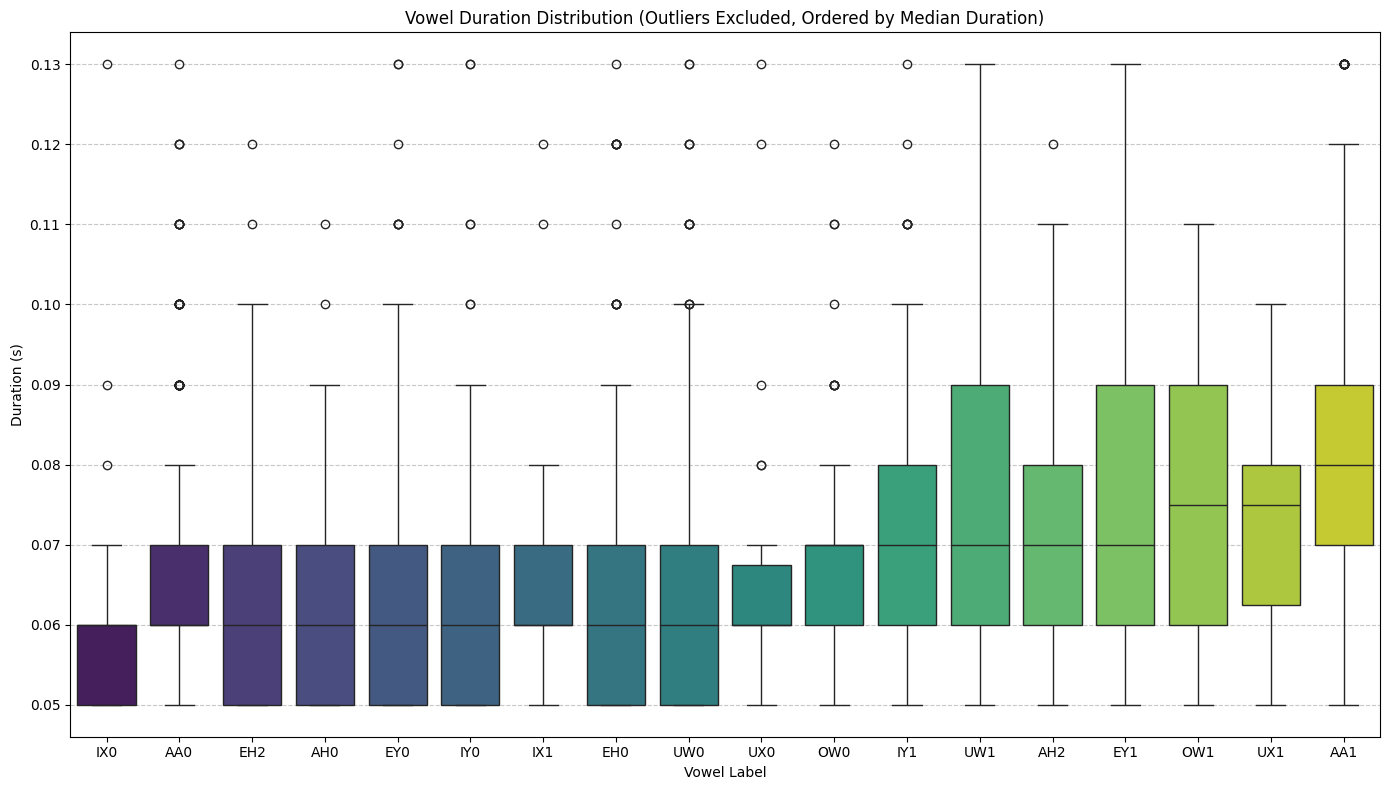

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'dur': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['dur'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['dur'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['dur'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['dur'].quantile(0.25)
    Q3 = vowels_df['dur'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['dur'] >= lower_bound) & (vowels_df['dur'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['dur'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Duration Distribution (Outliers Excluded, Ordered by Median Duration)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['dur'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['dur'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='dur', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-1973213032.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 8.93, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1  -0.1649    1.0 -1.0558  0.7259  False
   AA0    AH0  -2.3407    0.0 -3.4475 -1.2338   True
   AA0    AH2  -0.2801    1.0  -2.754  2.1938  False
   AA0    EH0  -2.5816    0.0 -3.6777 -1.4855   True
   AA0    EH2  -0.7301    1.0 -3.3717  1.9114  False
   AA0    EY0   0.1944    1.0 -1.0512    1.44  False
   AA0    EY1  -0.7866 0.2018  -1.703  0.1297  False
   AA0    IX0  -1.7348 0.6649 -4.3398  0.8702  False
   AA0    IX1  -1.2835 0.9755 -4.0035  1.4365  False
   AA0    IY0  -0.7196 0.9056 -2.0301  0.5909  False
   AA0    IY1  -0.7762  0.923 -2.2259  0.6735  False
   AA0    OW0  -0.5428 0.9998 -2.2808  1.1951  False
   AA0    OW1  -0.0462 

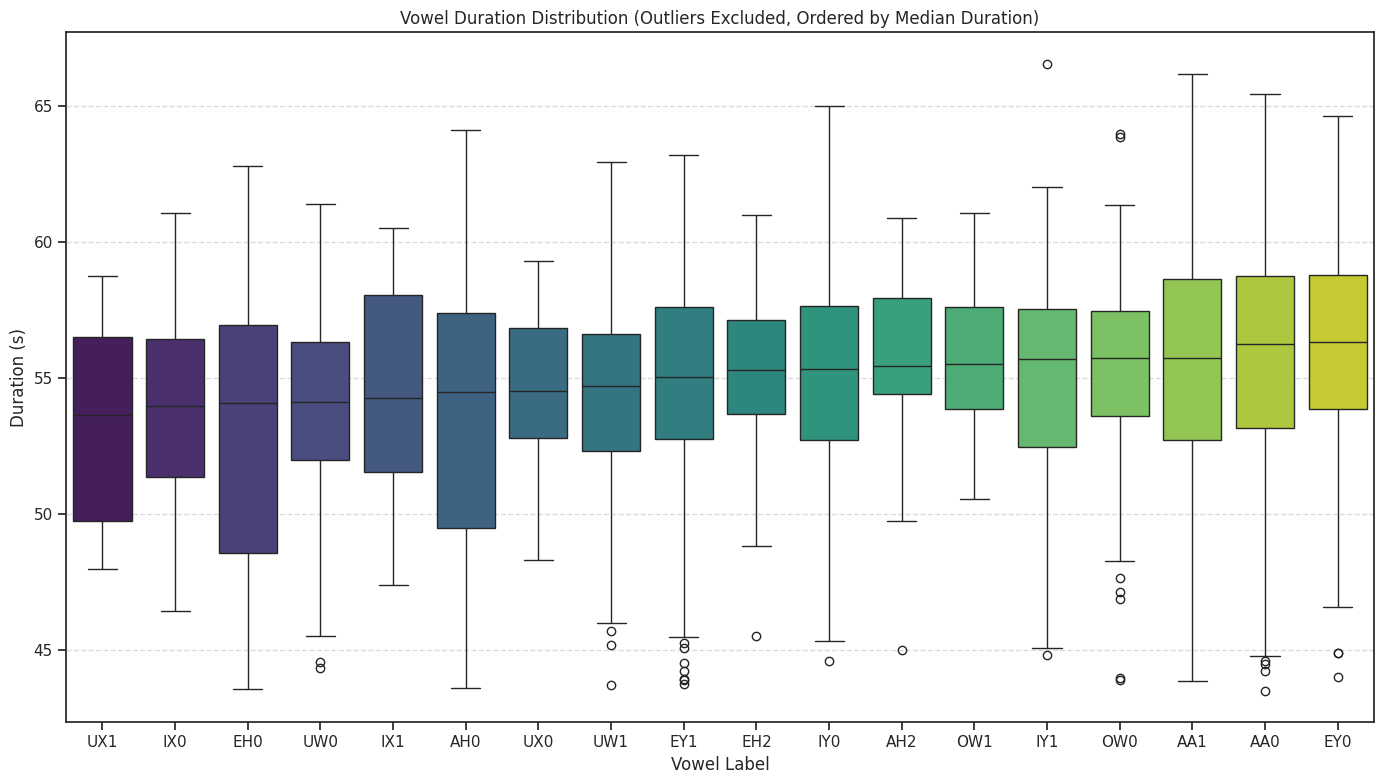

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'intensity': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['intensity'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['intensity'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['intensity'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['intensity'].quantile(0.25)
    Q3 = vowels_df['intensity'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['intensity'] >= lower_bound) & (vowels_df['intensity'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['intensity'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Intensity Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Intensity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['intensity'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['intensity'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='intensity', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-1678497727.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 28.04, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
   AA0    AA1 -19.9785    0.0  -28.7675 -11.1894   True
   AA0    AH0 -20.0866    0.0  -30.6222   -9.551   True
   AA0    AH2  -8.0782 0.9997  -32.8862  16.7297  False
   AA0    EH0  -24.085    0.0  -34.7414 -13.4286   True
   AA0    EH2   9.8898  0.997  -15.5497  35.3293  False
   AA0    EY0   12.609 0.0423    0.1835  25.0345   True
   AA0    EY1 -21.9587    0.0  -31.0082 -12.9092   True
   AA0    IX0  22.5499 0.2146   -3.9451  49.0448  False
   AA0    IX1 -15.5932 0.8571  -42.4733  11.2868  False
   AA0    IY0   7.0501 0.9115   -5.8937  19.9939  False
   AA0    IY1  -0.8301    1.0  -14.9853  13.3252  False
   AA0    OW0  25.6533    0.0    

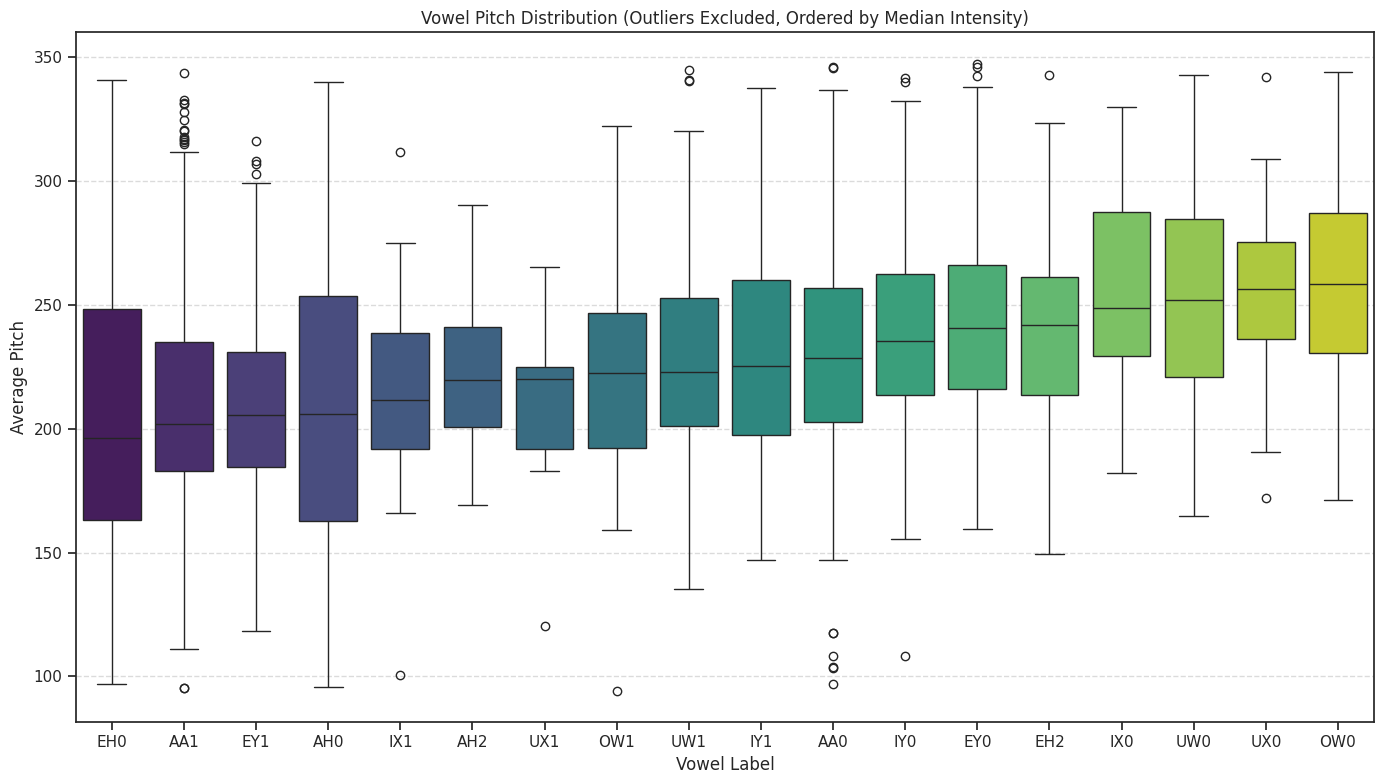

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'f0': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['f0'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['f0'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['f0'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['f0'].quantile(0.25)
    Q3 = vowels_df['f0'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['f0'] >= lower_bound) & (vowels_df['f0'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['f0'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Pitch Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Average Pitch')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['f0'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['f0'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='f0', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

LingMethodsHub

In [ ]:
#Import libraries

import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

In [ ]:
def vowelplot (vowelcsv, color=None, F1="F1", F2="F2", vowel="Vowel", title="Vowel Plot", unit="Hz", logscale=True):

    #Set some parameters for the chart itself
    sns.set(style='ticks', context='notebook')
    plt.figure(figsize=(6,6))

    # If there's an argument for color, determine whether it's likely to be categorical
    ## If it's a string (text), use a categorical color palette
    ## If it's a number, use a sequential color palette
    if color != None:
        if type(vowelcsv[color].iloc[0])==str:
            pal = "husl"
        else:
            pal = "viridis"

        pl = sns.scatterplot(x = F2,
                             y = F1,
                             hue = color,
                             data = vowelcsv,
                             palette = pal)

    # If no color argument is given, don't specify hue, and no palette needed
    else:
        pl = sns.scatterplot(x = F2,
                             y = F1,
                             data = vowelcsv)


    #Invert axes to correlate with articulatory space!
    pl.invert_yaxis()
    pl.invert_xaxis()

    #Add unit to the axis labels
    F1name = str("F1 ("+unit+")")
    F2name = str("F2 ("+unit+")")
    laby = plt.ylabel(F1name)
    labx = plt.xlabel(F2name)

    if logscale == True:
        pl.loglog()
        pl.yaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.yaxis.set_minor_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_minor_formatter(ticker.ScalarFormatter())

    # Add vowel labels

    if vowel != None:
        for line,row in vowelcsv.iterrows():
            pl.text(vowelcsv[F2][line]+0.1,
                    vowelcsv[F1][line],
                    vowelcsv[vowel][line],
                    horizontalalignment = 'left',
                    size = 14, # Edit for larger plots!
                    color = 'black',
                   # weight = 'semibold' # Uncomment for larger plots!
                   )

    pl.set_title(title)
    plt.show()

    return pl



def barkify (data, formants):
    # For each formant listed, make a copy of the column prefixed with z
    for formant in formants:
        for ch in formant:
            if ch.isnumeric():
                num = ch
        formantchar = (formant.split(num)[0])
        name = str(formant).replace(formantchar,'z')
        # Convert each value from Hz to Bark
        data[name] = 26.81/ (1+ 1960/data[formant]) - 0.53
    # Return the dataframe with the changes
    return data

def Lobify (data, group, formants):
    zscore = lambda x: (x - x.mean()) / x.std()
    for formant in formants:
        name = str("zsc_" + formant)
        col = data.groupby([group])[formant].transform(zscore)
        data.insert(len(data.columns), name, col)
    return data

In [ ]:
voweldata = pd.read_csv('all_chuvash_vowel_points.csv')

In [ ]:
voweldata.sample(5)

,F1,F2,F3,B1,B2,B3,max_formant,smooth_error,time,rel_time,...,word,stress,dur,pre_word,fol_word,pre_seg,fol_seg,abs_pre_seg,abs_fol_seg,context
2887,683.096539,1793.943643,3109.705708,3.528570,4.243757,4.311609,5692.307692,0.000480,2.411375,0.035,...,сарӑлтӑр,1.0,0.08,ан,тесе,S,R,S,R,internal
2795,408.962049,712.162417,3677.272448,3.670990,3.229005,4.288805,6410.256410,0.000463,2.687375,0.047,...,усӑ,1.0,0.12,унпа,курса,#,S,AA1,S,initial
2753,381.488477,876.050818,3048.055029,3.910847,3.230444,4.620701,6410.256410,0.001651,1.457375,0.027,...,пуҫ,1.0,0.06,пациента,мимин,P,ɕ,P,ɕ,internal
1743,343.596899,1862.306182,3172.450431,3.532066,3.230653,4.385695,5871.794872,0.000062,0.427375,0.027,...,ӳсӗр,0.0,0.06,<eps>,чухне,S,R,S,R,internal
436,433.577482,1345.788889,3041.886550,3.552825,3.482550,4.002879,4974.358974,0.000034,1.947375,0.027,...,тунӑ,1.0,0.06,йышӑну,<eps>,T,N,T,N,internal


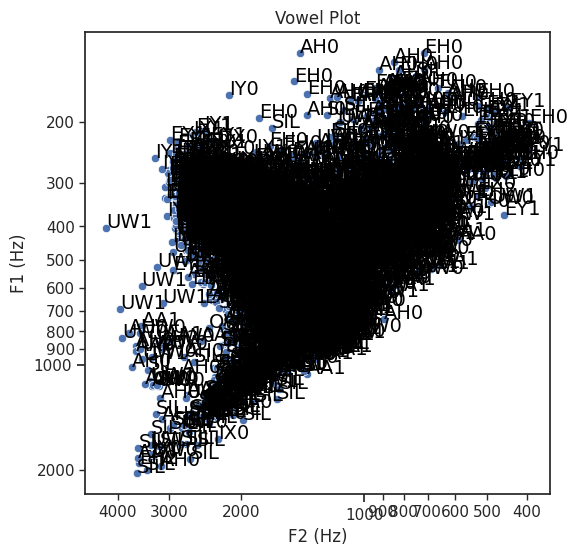

<Axes: title={'center': 'Vowel Plot'}, xlabel='F2 (Hz)', ylabel='F1 (Hz)'>

In [ ]:
vowelplot(voweldata,
          F1 = "F1",
          F2 = "F2",
          vowel = "label")